In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import time
import numpy as np
import xarray as xr
from itertools import product
from scipy.stats import pearsonr
import numpy as np
from numba import njit
from joblib import Parallel, delayed
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("/Users/wantongli/Documents/work/teaching/Germany_May2026/teaching/teaching_code_WL/")
os.chdir(base_dir)

# SWBM with runoff delay and performance boost

In the previous model version, the runoff function depended only on precipitation events. On days without rainfall, the model could not generate runoff. This led to strong spikes in runoff on rainy days, followed by an immediate drop back to zero. However, the observed runoff time series was much more constant and smoother.

To address this, we added a constant baseflow term, IOTA, to the model, allowing runoff to occur independently of precipitation. In the test time series, this led to substantial improvements.

At the same time, our analysis required an extremely large number of model iterations to calibrate the model successfully across many catchments. Therefore, we spent some time improving the model’s computational performance to save time in the long run.

In [4]:
temperature

<xarray.Dataset> Size: 900kB
Dimensions:      (time: 8329, y: 5, x: 5)
Coordinates:
  * time         (time) datetime64[ns] 67kB 2000-03-01 2000-03-02 ... 2022-12-19
  * y            (y) float64 40B 51.85 51.75 51.65 51.55 51.45
  * x            (x) float64 40B 8.55 8.65 8.75 8.85 8.95
    spatial_ref  int64 8B 0
Data variables:
    t2m          (time, y, x) float32 833kB nan nan nan 277.4 ... 276.1 nan nan
Attributes:
    title:        2 metre temperature
    version:      e1
    reference:    see:  http://apps.ecmwf.int/datasets/licences/copernicus/
    history:      created: Tue Jan 24 23:01:46 2023
    provided_by:  ECMWF/era5_land
    created_by:   uweber@bgc-jena.mpg.de

In [2]:
# All GRDC runoff time series
observed = xr.open_mfdataset(r"SWBM/data/observed.nc").load()
observed = observed.sel(time=slice('2000-03-01', '2022-12-19'))
area = observed["area"].values

# Bentfeld-specific model input time series
temperature = xr.open_mfdataset(r'SWBM/data/temperature.nc', combine='by_coords').load()
precipitation = xr.open_mfdataset(r'SWBM/data/precipitation.nc', combine='by_coords').load()
radiation = xr.open_mfdataset(r'SWBM/data/radiation.nc', combine='by_coords').load()
ndvi = xr.open_mfdataset(r'SWBM/data/ndvi.nc', combine='by_coords').load()

# Combined dataset across all grid cells
data = xr.Dataset()
data['temperature'] = temperature['t2m']
data['precipitation'] = precipitation['precipitation']
data['radiation'] = radiation['nr']
data['ndvi'] = ndvi['ndvi']
data = data.sel(time=slice('2000-03-01', '2022-12-19'))

# Mean input time series -> used for analysis
dataMean = data.mean(dim=("x", "y"))
# Convert units from m3/s to mm/day
dataMean['observed'] = observed["runoff"]*86400/(area*1000)

dataMean

<xarray.Dataset> Size: 333kB
Dimensions:        (time: 8329)
Coordinates:
  * time           (time) datetime64[ns] 67kB 2000-03-01 ... 2022-12-19
    spatial_ref    int64 8B 0
    id             int32 4B 6335082
Data variables:
    temperature    (time) float32 33kB 277.0 275.4 277.4 ... 267.1 269.5 276.8
    precipitation  (time) float64 67kB 0.01154 0.001884 ... 0.0001641 0.005312
    radiation      (time) float64 67kB 3.049e+06 3.901e+06 ... -1.258e+05
    ndvi           (time) float64 67kB 0.375 0.388 0.4011 ... 0.4226 0.4427
    observed       (time) float32 33kB 2.808 3.054 3.008 3.127 ... nan nan nan

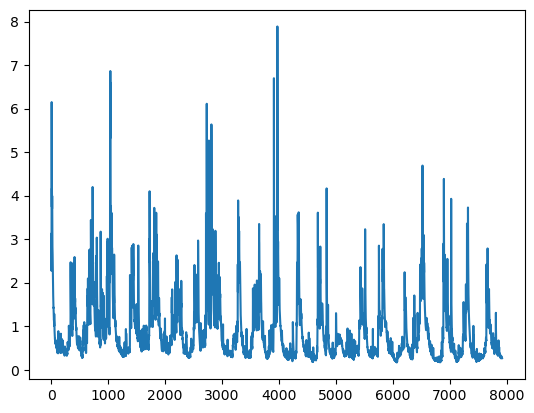

In [3]:
plt.plot(dataMean["observed"])
plt.show()

This works using the numba / njit library, which compiles Python code and allows it to run directly as machine code. For this to work efficiently, most of the code needs to be placed inside functions, so the model was adjusted accordingly.

In [4]:
@njit
def time_evolution_numba(temp, rad, prec, ndvi, c_s, alpha, beta, gamma, c_m, iota, temp_w, ndvi_w):
    #Initialize 
    length = len(temp)
    runoff_out = np.full(length, np.nan)
    evapo_out = np.full(length, np.nan)
    soil_mois_out = np.full(length, np.nan)
    snow_out = np.full(length, np.nan)

    # Transformations / Calculations for Setup
    conv = 1 / 2260000  # from J/day/m**2 to mm/day
    rad = rad * conv  # convert radiation to mm/day
    prec = prec * 10 **3 # from m/day to mm/day
    w = 0.9 * c_s
    snow = 0

    # --- calc_et_weight function ---
    ndvi = np.nan_to_num(ndvi, nan=0.0)
    normalized_temp = (temp - temp.min()) / (temp.max() - temp.min())
    normalized_ndvi = (ndvi - ndvi.min()) / (ndvi.max() - ndvi.min())
    et_weight = temp_w * normalized_temp + ndvi_w * normalized_ndvi
    beta_weighted = beta * et_weight

    for t in range(1, length):
        prec_t = prec[t-1]
        temp_t = temp[t-1]
        rad_t = rad[t-1]
        beta_t = beta_weighted[t-1]

        # ---- snow_function ----
        is_melting = temp_t > 273.15
        has_snow = snow >= 0.001

        if not is_melting:
            snow = snow + prec_t
            water = 0.0
        elif is_melting and has_snow:
            melt = c_m * (temp_t - 273.15)
            melt = min(melt, snow)
            snow = snow - melt
            water = melt + prec_t
        else:
            water = prec_t

        # --- !!! ADDED IOTA HERE  !!! ----    
        runoff = (water + iota) * (w / c_s) ** alpha
        evap = beta_t * (w / c_s) ** gamma * rad_t

        w = w + (water - runoff - evap)
        w = np.maximum(w, 0.0)

        # Store results
        runoff_out[t] = runoff
        evapo_out[t] = evap
        soil_mois_out[t] = w
        snow_out[t] = snow

    return runoff_out, evapo_out, soil_mois_out, snow_out

For easier handling, the function was embedded in a class. This is not strictly necessary and may even introduce a small bottleneck, but I find the following calibration code easier to understand this way.

In [5]:
class WaterModel:
    def __init__(self, params: dict, data):
        self.params = params
        self.data = data

    def run_simulation_whole_catchment(self):
        runoff,_,_,_= time_evolution_numba(
            self.data['temperature'].values,
            self.data['radiation'].values,
            self.data['precipitation'].values,
            self.data['ndvi'].values,
            self.params['c_s'],
            self.params['alpha'],
            self.params['beta'],
            self.params['gamma'],
            self.params['c_m'],
            self.params['iota'],
            self.params['temp_w'],
            self.params['ndvi_w']
        )
        return runoff

For comparison, we also use the original water-balance model as provided by Pia:

In [6]:
# Original SWBM from the course

def calc_et_weight(temp, lai, w):
    """Calculate influence of LAI and temperature on ET.
    Input: temp: temperature data [K]
           lai: leaf area index data [m**2/m**2]
           w: weights for temperature and lai"""
    # Get coefficients for temperature and lai
    temp_w, lai_w = w
    lai = np.nan_to_num(lai, nan=0)
    temp_min = temp.min()
    temp_max = temp.max()
    lai_min = lai.min()
    lai_max = lai.max()

    # Perform normalization
    normalized_temp = (temp - temp_min) / (temp_max - temp_min)
    normalized_lai = (lai - lai_min) / (lai_max - lai_min)

    # Weight Temperature and LAI
    et_coef = temp_w * normalized_temp + lai_w * normalized_lai
    return et_coef

def water_balance(w_t, prec_t, rad_t, snow_t, temp_t, cs, alpha, beta, gamma, c_m):
    """ Calculates the water balance for one time step as introduced in the lecture. Added features, such as snow"""
    snow_t, prec_t = snow_function(snow_t, prec_t, temp_t,
                             c_m)  # overwrites the precipitation (if snow melts or precipitation is accumulated as snow)
    runoff_t = runoff(w_t, prec_t, cs, alpha)
    evapo_t = evapotranspiration(w_t, rad_t, cs, beta, gamma)
    w_next = w_t + (prec_t - evapo_t - runoff_t)
    w_next = np.maximum(0, w_next)
    
    return runoff_t, evapo_t, w_next, snow_t

def runoff(w_t, prec_t, cs, alpha):
    return prec_t * (w_t / cs) ** alpha

def evapotranspiration(w_t, rad_t, cs, beta, gamma):
    return beta * (w_t / cs) ** gamma * rad_t

def snow_function(snow_t, prec_t, temp_t, c_m):
    # Determine if temperature is above freezing (melting condition)
    is_melting = temp_t > 273.15
    
    # Determine if there is already snow on the ground
    has_snow = snow_t >= 0.001

    if not is_melting:
        # Temperature is below or at freezing → precipitation adds to snow
        snow_out = snow_t + prec_t
        water_out = 0.0
    elif is_melting and has_snow:
        # Snow is present and temperature is above freezing → melt snow
        SnowMelt = c_m * (temp_t - 273.15)
        snow_out = snow_t - SnowMelt
        if snow_out < 0:
            SnowMelt = snow_t  # Can't melt more than exists
            snow_out = 0.0
        water_out = SnowMelt + prec_t
    else:
        # No snow, and temperature above freezing → all precip is rain
        snow_out = snow_t
        water_out = prec_t

    return snow_out, water_out

def time_evolution(temp, rad, prec, lai, params):
    runoff_out = np.full_like(temp, np.nan)
    evapo_out = np.full_like(temp, np.nan)
    soil_mois_out = np.full_like(temp, np.nan)
    snow_out = np.full_like(temp, np.nan)
    
    if np.all(np.isnan(lai)):
        #edge case for no vegetation
        return runoff_out, evapo_out, soil_mois_out, snow_out
    cs, alpha, gamma, beta, c_m, et_weight = params
    #conversion factor

    conv = 1 / 2260000  # from J/day/m**2 to mm/day
    rad = rad * conv  # convert radiation to mm/day
    prec = prec * 10 **3 # from m/day to mm/day
    
    w_0 = 0.9 * cs
    snow_0 = 0
    
    beta_weighted = beta * calc_et_weight(temp, lai, et_weight)
    
    for t in range(1, len(temp)):
        prec_t = prec[t-1]
        temp_t = temp[t-1]
        rad_t = rad[t-1]
        beta_weighted_t = beta_weighted[t-1]
        runoff_out[t], evapo_out[t], soil_mois_out[t], snow_out[t] = water_balance(
            w_0, prec_t, rad_t, snow_0, temp_t, cs, alpha, beta_weighted_t, gamma, c_m)
        w_0 = soil_mois_out[t]
        snow_0 = snow_out[t]
        
    return runoff_out, evapo_out, soil_mois_out, snow_out

## Performance comparison of the new and old model

To fully use numba's capacity, the code first has to run once in the normal way. The speed improvement becomes visible only from the second run onward, which is especially useful inside the calibration loop.

In [7]:
start_time = time.time()

params_old = [420, 8, 0.2, 0.8, 1.5, (0.75, 0.25)]
runoff_orig,_,_,_ = time_evolution(temp=dataMean["temperature"],
                            rad=dataMean["radiation"],
                            prec=dataMean["precipitation"],
                            lai=dataMean["ndvi"],
                            params=params_old)

duration = time.time() - start_time
print(f"calculations completed in {duration:.5f} seconds.")


calculations completed in 7.19006 seconds.


In [8]:
start_time = time.time()

params_new = {
    "c_s": 840,
    "alpha": 8,
    "gamma": 0.5,
    "beta": 0.8,
    "c_m": 2.0,
    "temp_w": 0.75,
    "ndvi_w": 0.5,
    "iota": 10
}
wm = WaterModel(params=params_new, data= dataMean)
runoff_delayed = wm.run_simulation_whole_catchment()

duration = time.time() - start_time
print(f"calculations completed in {duration:.5f} seconds.")

calculations completed in 0.99601 seconds.


In [9]:
# Filter for nans in ts, pearsonr functions doesnt like them
mask_orig = ~np.isnan(runoff_orig) & ~np.isnan(dataMean["observed"])
mask_delayed = ~np.isnan(runoff_delayed) & ~np.isnan(dataMean["observed"])

#Calculate Pearson R for old and new model
r_orig = pearsonr(runoff_orig[mask_orig], dataMean["observed"][mask_orig])[0]
r_delayed = pearsonr(runoff_delayed[mask_delayed], dataMean["observed"][mask_delayed])[0]
print("r original model: " + str(np.round(r_orig, 2)))
print("r delayed model: " + str(np.round(r_delayed, 2)))


r original model: 0.49
r delayed model: 0.87


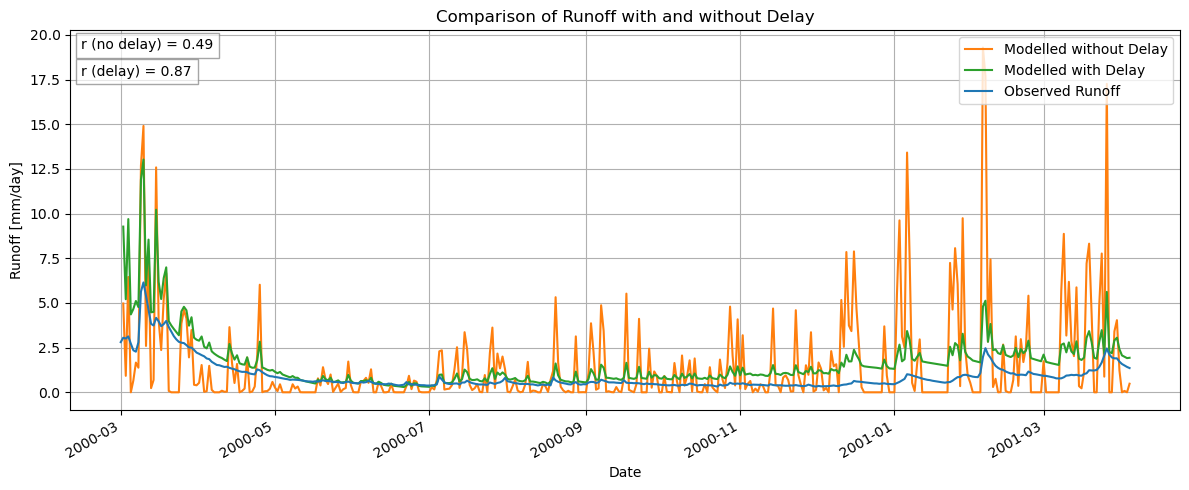

In [10]:
dates = dataMean["time"][:400].values
fig, ax = plt.subplots(figsize=(12, 5))

# Plot all series
ax.plot(dates, runoff_orig[:400], color='tab:orange', label="Modelled without Delay")
ax.plot(dates, runoff_delayed[:400], color='tab:green', label="Modelled with Delay")
ax.plot(dates, dataMean["observed"][:400], color='tab:blue', label="Observed Runoff")

# Labels and formatting
ax.set_title("Comparison of Runoff with and without Delay")
ax.set_xlabel("Date")
ax.set_ylabel("Runoff [mm/day]")
ax.grid(True)
ax.legend(loc="upper right")

# Pearson R Values
ax.text(0.01, 0.95, f"r (no delay) = {r_orig:.2f}", transform=ax.transAxes,
        fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
ax.text(0.01, 0.88, f"r (delay) = {r_delayed:.2f}", transform=ax.transAxes,
        fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Improve x-axis formatting
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Calibration

At the beginning of the calibration, an educated guess for a good parameter set (`initParams`) must be provided. From this, a set of candidate values is generated and then refined over a defined number of iterations (`numIter`). All possible combinations are tested, and the combination with the best Pearson correlation coefficient is saved for the next iteration. To further improve performance, we use the `joblib` library, which allows multiple test runs to be executed in parallel.

In [ ]:
class Calibrator:
    def __init__(self, initParams, rasterData, numIter = 3):
        self.params = initParams
        self.rasterData = rasterData
        self.numIter = numIter

    def create_paramsChoice(self, params, i):
        paramsChoice = {key: [
            value-value/(2**i),
            value, 
            value+value/(2**i)]
                for key, value in params.items()}
        return paramsChoice

    def split_data(self, data, splitPerc):
        leng = data.sizes["time"]
        maxYear = leng/365
        sample = np.random.randint(0, maxYear, int(maxYear*splitPerc))
        mask = np.zeros(leng, dtype=bool)
        for s in sample:
            mask[s*365:(s+1)*365] = True
        train = data.isel(time=np.where(~mask)[0])
        test = data.isel(time=np.where(mask)[0])

        return train, test

    def calibrate_iteration(self, paramsChoice, train):
        allCombinations = list(product(*paramsChoice.values()))
        param_dicts = [dict(zip(paramsChoice.keys(), combo)) for combo in allCombinations]

        observed = train["observed"].values
        nan_mask_obs = ~np.isnan(observed)        

        def evaluate(params):
            wm = WaterModel(params=params, data=train)
            runoff = wm.run_simulation_whole_catchment()
            mask = nan_mask_obs & ~np.isnan(runoff)

            r, _ = pearsonr(runoff[mask], observed[mask])
            return params, r
        
        # --- !!! Parallelisierung !!! --- you can change n_jobs to 4 or 8 depends on your cpu numebrs
        results = Parallel(n_jobs=-1)(delayed(evaluate)(params) for params in param_dicts)
        best_params, rTrain = max(results, key=lambda x: x[1])
        
        return best_params, rTrain
    
    def run_calibration(self):
        train, test = self.split_data(self.rasterData, 0.8)
        lParams = []
        lRTest = []
        lRTrain = []

        for i in range(1,self.numIter+1):
            paramsChoice = self.create_paramsChoice(self.params, i)
            newParams, rTrain = self.calibrate_iteration(paramsChoice, train)
            self.params = newParams
            lParams.append(newParams)

            wm = WaterModel(params=lParams[i-1], data=test)
            runoff = wm.run_simulation_whole_catchment()
            observed = test["observed"].values
            mask = ~np.isnan(observed)  & ~np.isnan(runoff)

            rTest, _ = pearsonr(runoff[mask], observed[mask])
            
            lRTest.append(rTest)
            lRTrain.append(rTrain)
        
        plt.plot(lRTest, label="test")
        plt.plot(lRTrain, label="train")
        plt.legend()
        plt.show()

        print("number of model runs: " + str(self.numIter*len(list(product(*paramsChoice.values())))))

        return lParams[-1], lRTest[-1]

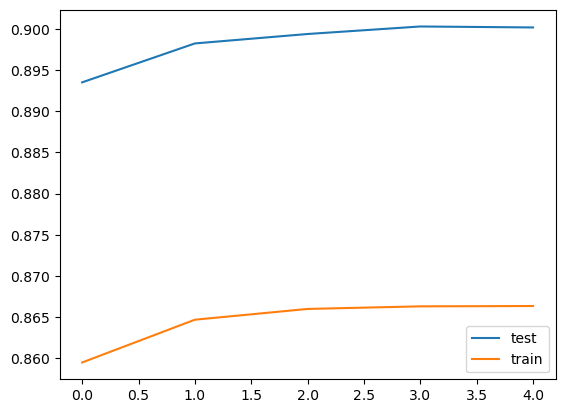

number of model runs: 32805
calculations completed in 9.67283 seconds.
c_s: 1713.043
alpha: 16.875
gamma: 0.879
beta: 0.775
c_m: 0.844
temp_w: 1.16
ndvi_w: 0.338
iota: 22.412


In [12]:
start_time = time.time()
cal = Calibrator(initParams=params_new, rasterData=dataMean, numIter=5)
paramsBest, r = cal.run_calibration()
duration = time.time() - start_time

print(f"calculations completed in {duration:.5f} seconds.")
for key, value in paramsBest.items():
    print(key + ": " + str(np.round(value, 3)))